In [2]:
# ==========================================
# 1. SETUP
# ==========================================
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
# Mount google drive
print("--- Mounting Google Drive ---")

--- Mounting Google Drive ---


In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
print(os.listdir('/content/drive/MyDrive'))

['Resume_Navdeep. (1).pdf', 'CV_NavdeepSingh.pdf (1) (1).pdf', 'CV_NavdeepSingh.pdf.pdf', 'Navdeep_Dmart research.pdf', 'CV___Navdeep.pdf', 'Ultratech - Navdeep Singh Chhabra(23NA30019).pdf', 'Excel Ultratech - Navdeep Singh(23NA30019) (1).xlsx', 'Excel Ultratech - Navdeep Singh(23NA30019).xlsx', 'Ultratech - Navdeep Singh Chhabra(23NA30019)(1).pdf', 'Pitch decks ', 'TASK 1 Internship.gdoc', 'CV_NavdeepSingh.pdf', 'Rapido  Task.pdf', 'CV_NavdeepSingh.pdf (1).pdf', 'Note[1].pdf', 'note_1[1].pdf', 't1.pdf', 'finarl irreg waves.pdf', 'CV_NavdeepSingh..pdf (1) (1).pdf', 'CV_NavdeepSingh..pdf (1).pdf', 'CV_Navdeep_Singhpdf.pdf.pdf', 'CV_Navdeep_Singh (1).pdf', 'CV_Navdeep_Singh.pdf', 'Week_10_Energy_Conv_Pros_24_25.pdf', 'Marine hydrodynamics ', 'CV_NavdeepSingh... (2).pdf.pdf', 'CV_NavdeepSingh... (1).pdf.pdf', 'CV_NavdeepSingh....pdf.pdf', 'CV_NavdeepSingh... (1).pdf-1.pdf', 'CV_NavdeepSingh....pdf-1.pdf', 'Copy of Client Requests - Intern (1).gsheet', 'Copy of Client Requests - Intern.gs

In [6]:
print(os.listdir('/content/drive/MyDrive'))

['Resume_Navdeep. (1).pdf', 'CV_NavdeepSingh.pdf (1) (1).pdf', 'CV_NavdeepSingh.pdf.pdf', 'Navdeep_Dmart research.pdf', 'CV___Navdeep.pdf', 'Ultratech - Navdeep Singh Chhabra(23NA30019).pdf', 'Excel Ultratech - Navdeep Singh(23NA30019) (1).xlsx', 'Excel Ultratech - Navdeep Singh(23NA30019).xlsx', 'Ultratech - Navdeep Singh Chhabra(23NA30019)(1).pdf', 'Pitch decks ', 'TASK 1 Internship.gdoc', 'CV_NavdeepSingh.pdf', 'Rapido  Task.pdf', 'CV_NavdeepSingh.pdf (1).pdf', 'Note[1].pdf', 'note_1[1].pdf', 't1.pdf', 'finarl irreg waves.pdf', 'CV_NavdeepSingh..pdf (1) (1).pdf', 'CV_NavdeepSingh..pdf (1).pdf', 'CV_Navdeep_Singhpdf.pdf.pdf', 'CV_Navdeep_Singh (1).pdf', 'CV_Navdeep_Singh.pdf', 'Week_10_Energy_Conv_Pros_24_25.pdf', 'Marine hydrodynamics ', 'CV_NavdeepSingh... (2).pdf.pdf', 'CV_NavdeepSingh... (1).pdf.pdf', 'CV_NavdeepSingh....pdf.pdf', 'CV_NavdeepSingh... (1).pdf-1.pdf', 'CV_NavdeepSingh....pdf-1.pdf', 'Copy of Client Requests - Intern (1).gsheet', 'Copy of Client Requests - Intern.gs

In [7]:
# Define Dataset Path
DATA_DIR = '/content/drive/MyDrive/Crop_Vision'

In [8]:
# Configuration Parameters
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001

In [9]:
# Check if dataset exists
if os.path.exists(DATA_DIR):
    print(f"\n[INFO] Dataset directory found: {DATA_DIR}")
    classes = os.listdir(DATA_DIR)
    print(f"[INFO] Classes found: {classes}")
else:
    print(f"\n[ERROR] Directory not found at {DATA_DIR}")
    print("Please check that your folder name in Google Drive matches the path exactly.")


[INFO] Dataset directory found: /content/drive/MyDrive/Crop_Vision
[INFO] Classes found: ['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [10]:
# ==========================================
# 2. DATA GENERATORS (AUGMENTATION)
# ==========================================
print("\n--- Preparing Data Generators ---")

# Training Data Generator (with Augmentation to prevent overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values
    rotation_range=30,          # Random rotations
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2        # 20% for validation
)



--- Preparing Data Generators ---


In [11]:
# Validation Data Generator (Only rescale)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [12]:
# Load Training Data
print("Loading Training Set:")
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',        # Integer labels for classes
    subset='training',
    shuffle=True,
    seed=42
)

Loading Training Set:
Found 1722 images belonging to 3 classes.


In [13]:
# Load Validation Data
print("Loading Validation Set:")
validation_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=42
)


Loading Validation Set:
Found 429 images belonging to 3 classes.


In [14]:
# Print class indices for reference
print(f"\n[INFO] Class Mappings: {train_generator.class_indices}")


[INFO] Class Mappings: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [15]:
# ==========================================
# 3. MODEL BUILDING (VGG16 TRANSFER LEARNING)
# ==========================================
print("\n--- Building VGG16 Model ---")

# Load VGG16 Base (Pre-trained on ImageNet)
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,          # Exclude the top classification layer
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)


--- Building VGG16 Model ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Freeze the base layers so they don't train
vgg_base.trainable = False

In [17]:
# Build the complete model
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),               # Dropout to reduce overfitting
    Dense(3, activation='softmax') # 3 output neurons for the 3 classes
])

In [18]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Display Model Summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,992,515 (68.64 MB)

 Trainable params: 3,277,827 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
# ==========================================
# 4. TRAINING
# ==========================================
print(f"\n--- Starting Training for {EPOCHS} Epochs ---")

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)


--- Starting Training for 15 Epochs ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 899s 17s/step - accuracy: 0.6009 - loss: 1.0177 - val_accuracy: 0.8846 - val_loss: 0.3955
Epoch 2/15
 1/53 ━━━━━━━━━━━━━━━━━━━━ 11:13 13s/step - accuracy: 0.6562 - loss: 0.5851

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


53/53 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.6562 - loss: 0.5851 - val_accuracy: 0.8822 - val_loss: 0.3966
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 874s 17s/step - accuracy: 0.7947 - loss: 0.5113 - val_accuracy: 0.9135 - val_loss: 0.2891
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.9375 - loss: 0.3930 - val_accuracy: 0.9087 - val_loss: 0.2912
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 855s 16s/step - accuracy: 0.8467 - loss: 0.4115 - val_accuracy: 0.9327 - val_loss: 0.2399
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.9688 - loss: 0.2105 - val_accuracy: 0.9255 - val_loss: 0.2447
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 924s 17s/step - accuracy: 0.8437 - loss: 0.3958 - val_accuracy: 0.9399 - val_loss: 0.2106
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - accuracy: 0.8125 - loss: 0.3942 - val_accuracy: 0.9279 - val_loss: 0.2147
Epoch 9/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 881s 16s/step - accuracy: 0.8969 - loss: 0.2920 - val_accuracy: 0.9471 - val_loss

In [21]:
model_save_path = '/content/drive/MyDrive/Crop_Vision.h5'

In [22]:
model.save(model_save_path)

In [23]:
print(f"\n[SUCCESS] Model saved as '{model_save_path}'")


[SUCCESS] Model saved as '/content/drive/MyDrive/Crop_Vision.h5'


In [24]:
# ==========================================
# 5. VISUALIZATION
# ==========================================
print("\n--- Plotting the Results ---")

# Extract history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))


--- Plotting the Results ---


In [25]:
# Create the plot
plt.figure(figsize=(16, 6))

<Figure size 1600x600 with 0 Axes>

<Figure size 1600x600 with 0 Axes>

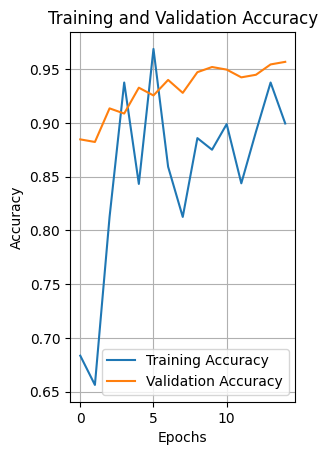

In [26]:
# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

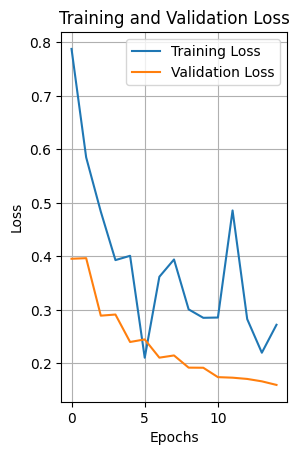

In [27]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

In [28]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [29]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]


In [30]:
print("\n----- Final Results -----")
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Training Loss: {final_train_loss:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")


----- Final Results -----
Training Accuracy: 0.8994
Validation Accuracy: 0.9567
Training Loss: 0.2721
Validation Loss: 0.1596
